In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

In [6]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
print("shape:", df.shape)
print("\nFirst 5 rows:")
df.head


shape: (1407328, 6)

First 5 rows:


<bound method NDFrame.head of          Unnamed: 0                                           headline  \
0                 0            Stocks That Hit 52-Week Highs On Friday   
1                 1         Stocks That Hit 52-Week Highs On Wednesday   
2                 2                      71 Biggest Movers From Friday   
3                 3       46 Stocks Moving In Friday's Mid-Day Session   
4                 4  B of A Securities Maintains Neutral on Agilent...   
...             ...                                                ...   
1407323     1413844             Top Narrow Based Indexes For August 29   
1407324     1413845  Recap: Wednesday's Top Percentage Gainers and ...   
1407325     1413846  UPDATE: Oppenheimer Color on China Zenix Auto ...   
1407326     1413847  Oppenheimer Initiates China Zenix At Outperfor...   
1407327     1413848  China Zenix Auto International Opens For Tradi...   

                                                       url          publisher  \


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [9]:
df.isnull().sum()


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [ ]:
df["headline_length"] = df["headline"].str.len()


In [11]:
df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

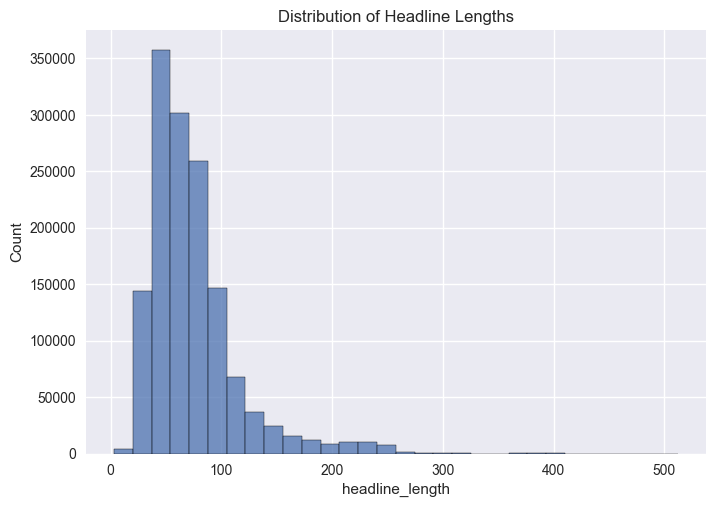

In [ ]:
#visualization
sns.histplot(df["headline_length"], bins=30)
plt.title("Distribution of Headline Lengths")
plt.show()

In [13]:
#publisher analysis
publisher_counts = df["publisher"].value_counts()
publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

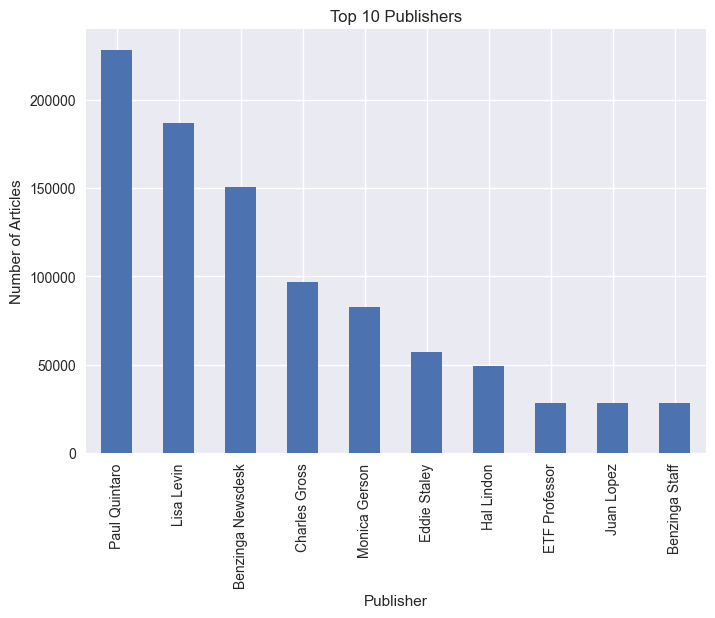

In [14]:
publisher_counts.head(10).plot(kind="bar")
plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.show()

In [19]:
df["date"] = pd.to_datetime(df["date"], utc=True, format='mixed')
print('date range:')
print("from:", df['date'].min())
print("To:", df['date'].max())

date range:
from: 2009-02-14 00:00:00+00:00
To: 2020-06-11 21:12:35+00:00


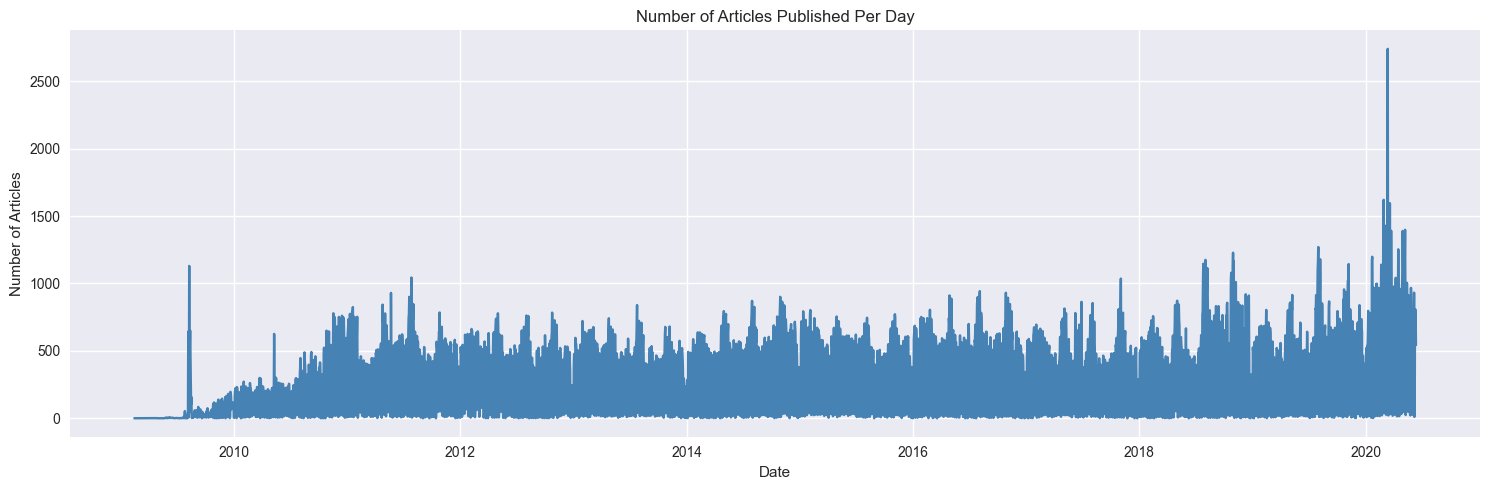

In [22]:
# Articles published per day
df['date_only'] = df['date'].dt.date

daily_counts = df.groupby('date_only').size()

plt.figure(figsize=(15, 5))
daily_counts.plot(kind='line', color='steelblue')
plt.title('Number of Articles Published Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["headline"])

In [29]:
# Print top 10 keywords as a list
print("Top 10 Most Common Keywords:")
print("-" * 30)
for i, (word, count) in enumerate(word_counts, 1):
    print(f"{i}. {word}: {count}")

Top 10 Most Common Keywords:
------------------------------
1. stocks: 11970
2. est: 9667
3. eps: 9122
4. shares: 8749
5. reports: 8020
6. market: 6514
7. update: 6495
8. earnings: 6277
9. top: 5979
10. announces: 5452


C:\Users\HP\AppData\Local\Temp\ipykernel_6268\285786413.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x='count', y='word', palette='Blues_d')


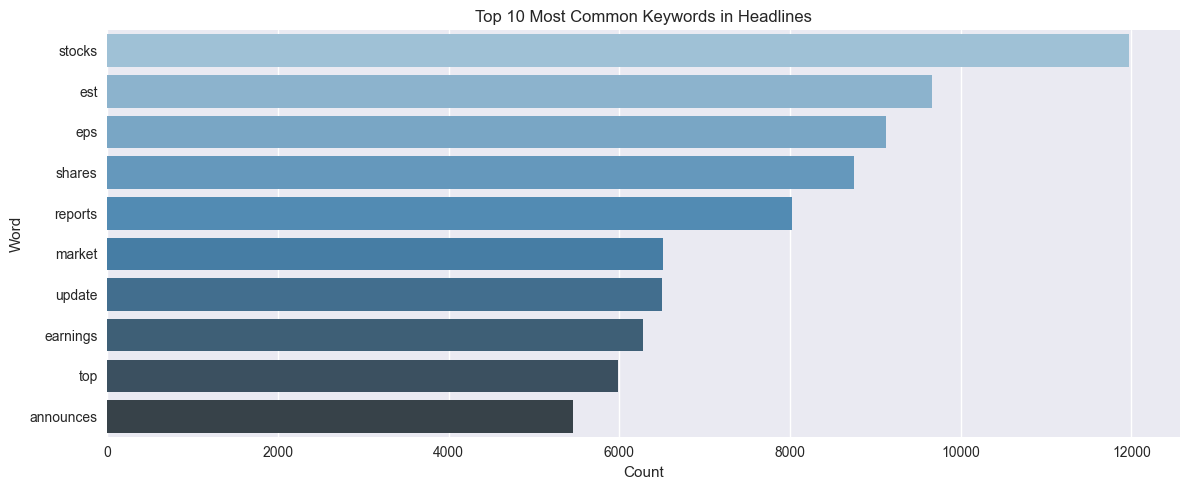

In [28]:

from collections import Counter
import re

# Use only first 100,000 rows to save memory
sample = df['headline'].dropna().head(100000)

# Clean and split into words
all_words = ' '.join(sample).lower()
all_words = re.sub(r'[^a-z\s]', '', all_words)
words = all_words.split()

# Remove stop words
stop_words = {'the', 'a', 'an', 'and', 'or', 'in', 'on', 'at', 'to', 'for', 
              'of', 'is', 'are', 'was', 'with', 'from', 'by', 'as', 'its',
              'it', 'this', 'that', 'be', 'has', 'have', 'had', 'will', 'up'}
words = [w for w in words if w not in stop_words and len(w) > 2]

# Count top 10 words
word_counts = Counter(words).most_common(10)
words_df = pd.DataFrame(word_counts, columns=['word', 'count'])

plt.figure(figsize=(12, 5))
sns.barplot(data=words_df, x='count', y='word', palette='Blues_d')
plt.title('Top 10 Most Common Keywords in Headlines')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.show()